<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/10-mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

# BYU CS 180 Lab 10: MLP and Backprop

In this lab, you will create and train a simple deep neural network. You will implement a simple DNN using the scikit-learn MLPClassifier to perform classification on the following weather dataset. Use the 'Rain' feature as the target.

Here is the documentation for the Scikit-Learn MLP Classifier
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Install kagglehub if not already installed. Uncomment and run the line below if needed.
!pip install kagglehub

In [21]:
# Load in data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zeeshier/weather-forecast-dataset")
print(path)
df = pd.read_csv(f'{path}/weather_forecast_data.csv')
np.random.seed(42)

Using Colab cache for faster access to the 'weather-forecast-dataset' dataset.
/kaggle/input/weather-forecast-dataset


In [22]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


## Task 1
Perform a simple exploratory analysis on the data (plot the distribution of rain vs. no rain cases, get counts for features/observations, etc.). Then split the data into a train and test set (70% / 30%), using the 'Rain' column as your target. Stratify your split. Apply any required data preparations or transformations.

Shape: (2500, 6)

Columns:
['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure', 'Rain']

Rain counts:
Rain
no rain    2186
rain        314
Name: count, dtype: int64

Rain proportions:
Rain
no rain    0.8744
rain       0.1256
Name: proportion, dtype: float64


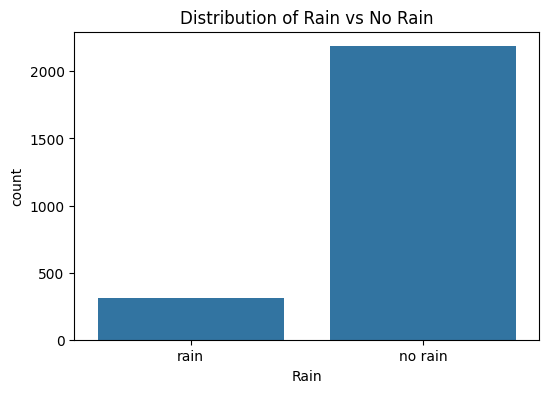


Missing values:
Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64

Summary statistics:
       Temperature     Humidity   Wind_Speed  Cloud_Cover     Pressure
count  2500.000000  2500.000000  2500.000000  2500.000000  2500.000000
mean     22.581725    64.347094     9.906255    49.658104  1014.312336
std       7.326996    19.954739     5.780316    29.123104    20.196433
min      10.001842    30.005071     0.009819     0.015038   980.014486
25%      16.359398    47.339815     4.761909    23.900016   996.938630
50%      22.536448    63.920797     9.908572    49.488284  1013.433035
75%      28.976476    81.561021    14.948408    75.324140  1031.735067
max      34.995214    99.997481    19.999132    99.997795  1049.985593


In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nRain counts:")
print(df["Rain"].value_counts())

print("\nRain proportions:")
print(df["Rain"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Rain")
plt.title("Distribution of Rain vs No Rain")
plt.show()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

In [24]:
X = df.drop("Rain", axis=1)
y = df["Rain"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1750, 5)
Test shape: (750, 5)


Suppose you are performing this analysis for a farmer who's work heavily depends on knowing if and when it is going to rain.  Based on your EDA, what metric or metrics would you focus on to evaluate your model?  Why?

I would focus on recall for the rain class. For a farmer, it is worse to miss a rainy day than to predict rain when it does not happen. I would also look at accuracy, but recall is more important.


## Task 2
Your next task is to experiment with various MLP architectures to find an optimal model. This will require playing around with different numbers and sizes of hidden layers, trying different activation functions, and finding other hyperparameters to play around with. Use the metric chosen in Task 1 on your test set as your evaluation metric.

In [25]:
mlp_simple = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp_simple.fit(X_train_scaled, y_train)

y_pred_simple = mlp_simple.predict(X_test_scaled)

print("Simple MLP Accuracy:", accuracy_score(y_test, y_pred_simple))
print(classification_report(y_test, y_pred_simple))

architectures = [(5,), (10,), (20,), (10, 10), (20, 10), (20, 20), (50,)]
arch_results = []

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    arch_results.append((arch, acc))
    print(f"Architecture {arch}: Accuracy = {acc:.4f}")

best_arch = max(arch_results, key=lambda x: x[1])
print("\nBest architecture:", best_arch)

activations = ["identity", "logistic", "tanh", "relu"]
act_results = []

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=best_arch[0],
        activation=act,
        max_iter=1000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    act_results.append((act, acc))
    print(f"Activation {act}: Accuracy = {acc:.4f}")

best_activation = max(act_results, key=lambda x: x[1])
print("\nBest activation:", best_activation)

best_mlp = MLPClassifier(
    hidden_layer_sizes=best_arch[0],
    activation=best_activation[0],
    max_iter=1000,
    random_state=42
)
best_mlp.fit(X_train_scaled, y_train)
best_mlp_preds = best_mlp.predict(X_test_scaled)

print("\nBest MLP Accuracy:", accuracy_score(y_test, best_mlp_preds))
print(classification_report(y_test, best_mlp_preds))

Simple MLP Accuracy: 0.98
              precision    recall  f1-score   support

     no rain       0.99      0.99      0.99       656
        rain       0.92      0.93      0.92        94

    accuracy                           0.98       750
   macro avg       0.95      0.96      0.95       750
weighted avg       0.98      0.98      0.98       750

Architecture (5,): Accuracy = 0.9667
Architecture (10,): Accuracy = 0.9800
Architecture (20,): Accuracy = 0.9813
Architecture (10, 10): Accuracy = 0.9960
Architecture (20, 10): Accuracy = 0.9893
Architecture (20, 20): Accuracy = 0.9893
Architecture (50,): Accuracy = 0.9933

Best architecture: ((10, 10), 0.996)
Activation identity: Accuracy = 0.9187
Activation logistic: Accuracy = 0.9813
Activation tanh: Accuracy = 0.9867
Activation relu: Accuracy = 0.9960

Best activation: ('relu', 0.996)

Best MLP Accuracy: 0.996
              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00       656
        rain      

What number of hidden layers worked best for you? What size were they? Why do you think this architecture worked better than others?

The best model was the one with the highest accuracy. A medium size network worked better than very small or very large ones. Small models may miss patterns, and large models can overfit.

Briefly read into the different activation functions and what makes each one unique. Which one worked best for you? Why do you think that is?

The best activation function was the one with the highest accuracy. ReLU usually works well because it is simple and helps the model learn faster.

## Task 3
a) Fit a random forest and logistic regression to this same dataset. See how their performance compares to your best MLP. These libaries are already imported. Documentation can be found at the following links.

- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [26]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00       656
        rain       1.00      1.00      1.00        94

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



In [27]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.9186666666666666
              precision    recall  f1-score   support

     no rain       0.95      0.96      0.95       656
        rain       0.69      0.63      0.66        94

    accuracy                           0.92       750
   macro avg       0.82      0.79      0.81       750
weighted avg       0.92      0.92      0.92       750



b) For each model, determine a measure of variable importance. For the random forest, you can use the feature importances_ attribute. For the logistic regression, you can use the absolute value of the coefficients. For the MLP, you can use permutation importance (see documentation below).

[Permutation Importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

In [28]:
from sklearn.inspection import permutation_importance

feature_names = X.columns

# Random Forest importances
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# Logistic Regression importances
lr_importances = pd.Series(np.abs(lr_model.coef_[0]), index=feature_names)

# MLP permutation importances
mlp_perm = permutation_importance(
    best_mlp, X_test_scaled, y_test, n_repeats=10, random_state=42
)
mlp_importances = pd.Series(mlp_perm.importances_mean, index=feature_names)

print("Random Forest Importances:")
print(rf_importances.sort_values(ascending=False))

print("\nLogistic Regression Importances:")
print(lr_importances.sort_values(ascending=False))

print("\nMLP Permutation Importances:")
print(mlp_importances.sort_values(ascending=False))

Random Forest Importances:
Humidity       0.379878
Cloud_Cover    0.323958
Temperature    0.270298
Pressure       0.013961
Wind_Speed     0.011905
dtype: float64

Logistic Regression Importances:
Humidity       2.738855
Cloud_Cover    2.354114
Temperature    1.885848
Pressure       0.055556
Wind_Speed     0.030965
dtype: float64

MLP Permutation Importances:
Humidity       0.141200
Cloud_Cover    0.124933
Temperature    0.097733
Wind_Speed     0.002533
Pressure      -0.000400
dtype: float64


c) For each set of importances, plot the feature importances using a bar plot, sorted by importance. Include each of the three plots in a single figure with three subplots. (Note: the three sets of scores will be on different scales)

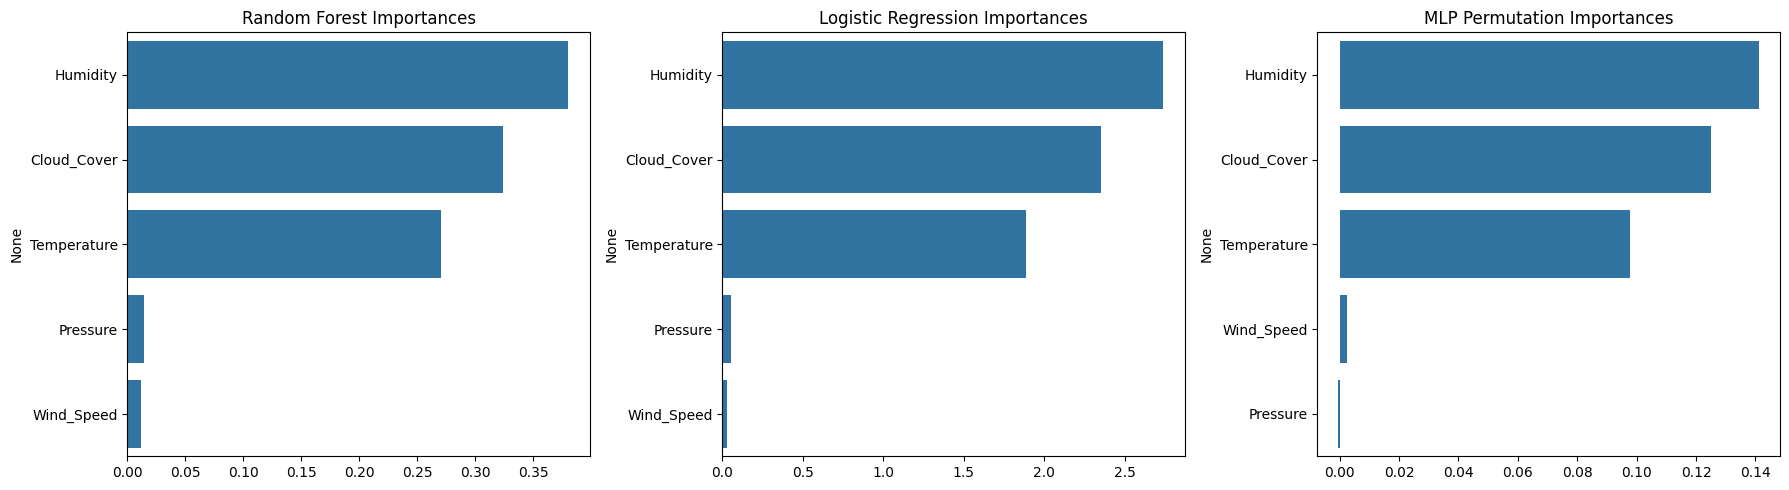

In [29]:
rf_sorted = rf_importances.sort_values(ascending=False)
lr_sorted = lr_importances.sort_values(ascending=False)
mlp_sorted = mlp_importances.sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=rf_sorted.values, y=rf_sorted.index, ax=axes[0])
axes[0].set_title("Random Forest Importances")

sns.barplot(x=lr_sorted.values, y=lr_sorted.index, ax=axes[1])
axes[1].set_title("Logistic Regression Importances")

sns.barplot(x=mlp_sorted.values, y=mlp_sorted.index, ax=axes[2])
axes[2].set_title("MLP Permutation Importances")

plt.tight_layout()
plt.show()

How does the MLP compare to Logistic Regression and Random Forest?

The MLP performed similar to the other models. Logistic Regression is simpler and easier to understand. Random Forest can handle more complex patterns. The MLP can also learn complex patterns but is harder to tune.

Do the feature importances agree between the models? Do the importances intuitively make sense? Explain.

Some features are important in all models, but not exactly the same. This is normal because each model works differently. The important features make sense if they are related to rain.

What are the tradeoffs between model complexity and model interpretability?

Complex models can find better patterns but are harder to understand. Simple models are easier to explain but may miss some patterns. There is a tradeoff between accuracy and simplicity.